## LỌC LĨNH VỰC, TẠO FEATURE_RECENT, CÓ XỬ LÝ NAN CHO FEATURE_RECENT

In [2]:
import json
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('creator_expand.csv')

In [7]:
df['contentLabels'].isna().sum()


2456

In [8]:
df['contentLabels'] = df['contentLabels'].fillna('Unknown')

In [9]:
target_labels = {
    'School Education',
    'Career Development',
    'Humanities & Science'
    
    'Fitness'
    'Health & Wellness'
    'Fishing, Hunting, & Camping'
    'Traditional Sports'
    'Extreme Sports'
    'Sports News'

    'Food Display & Reviews',
    'Beverages & Production',
    'Mukbang & Food Tasting',
    'Cooking & Recipes',
    'Restaurant Exploration',

    'Nail Art & Care',
    'Beauty Tutorials & Tips',
    'Hair Design & Care',
    'Theater & Stage',

    'Music',
    'Dance',
    'Animation & Cosplay',
    'Entertainment News',
    'Supernatural & Horror'
}

df['contentLabels_list'] = df['contentLabels'].str.split('|')

df = df[
    df['contentLabels_list'].apply(lambda x: any(label in target_labels for label in x))
]

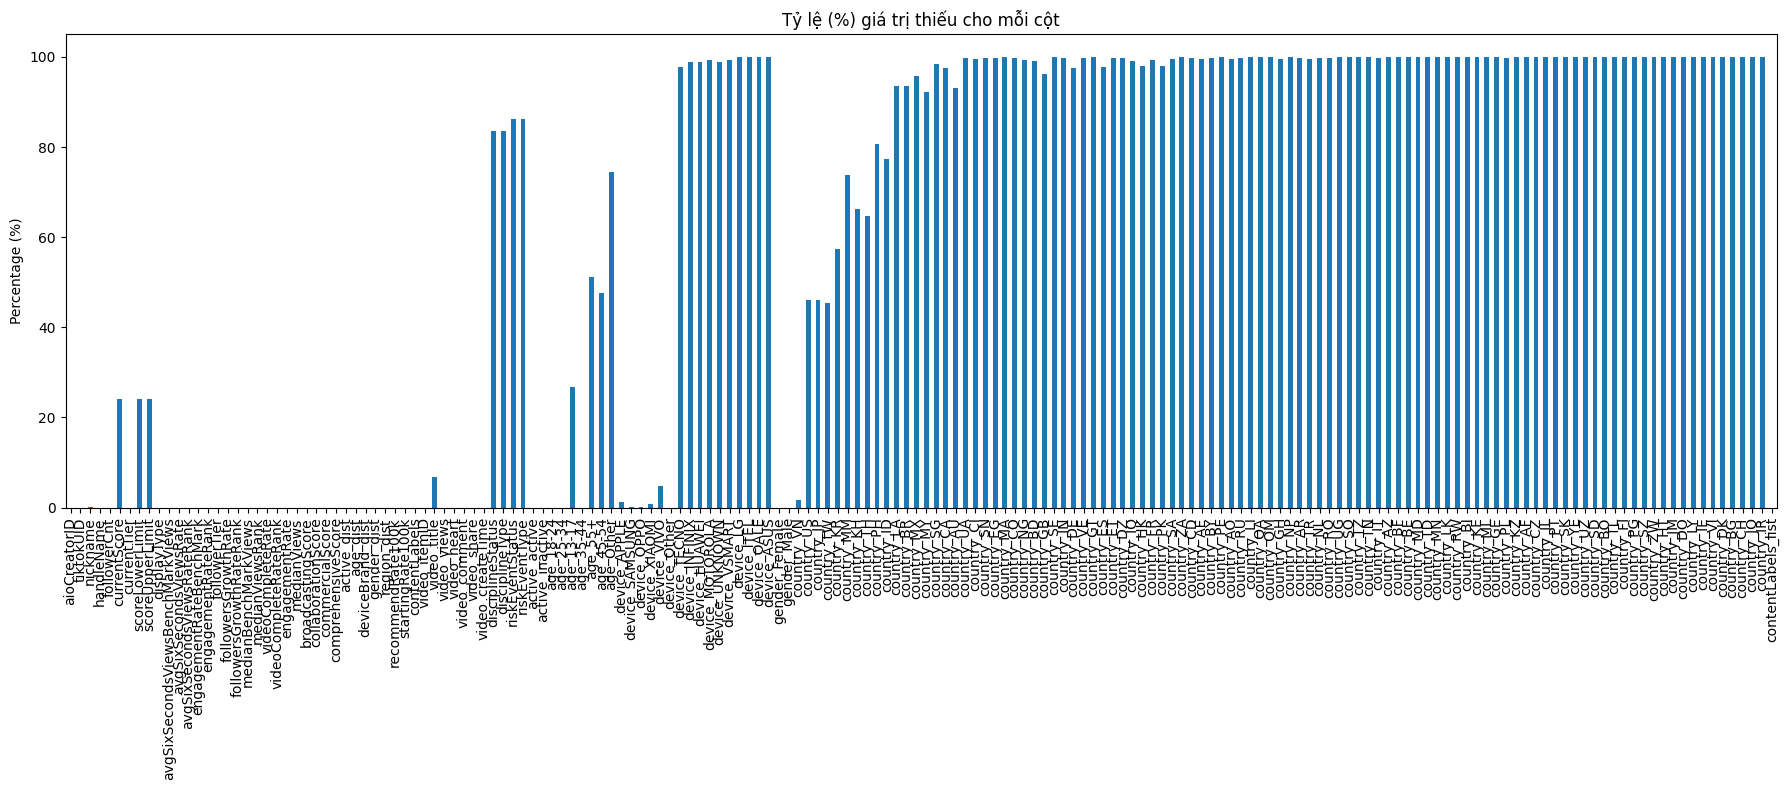

In [10]:
a = df.isna().mean() * 100  

plt.figure(figsize=(18, 8))
a.plot(kind='bar')

plt.title('Tỷ lệ (%) giá trị thiếu cho mỗi cột')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [11]:
# bỏ các cột có quá nhiều giá trị thiếu (hơn 90%)
df = df.loc[:, df.isna().mean() < 0.9]


In [12]:
# Bỏ cột 
DROP_VIDEO_COLS = [
    'aioCreatorID', 'tiktokUID', 'nickname',
    'active_dist', 'age_dist', 'deviceBrand_dist', 'gender_dist', 'region_dist',
    'video_itemID', 'video_title', 'currentTier','currentScore', 'scoreLowerLimit', 'scoreUpperLimit', 'displayType','currentTier',
    'disciplineStatus', 'disciplineType','riskEventStatus', 'riskEventType','contentLabels_list',
]
df = df.drop(columns=[c for c in DROP_VIDEO_COLS if c in df.columns])

In [13]:
# Điền 0 cho tất cả NaN còn lại (các chỉ số phân phối, performance…)
df = df.fillna(0)

print(f'[processing] Shape cuối: {df.shape}')
print(f'[processing] Giá trị thiếu còn lại: {df.isna().sum().sum()}')

[processing] Shape cuối: (74466, 55)
[processing] Giá trị thiếu còn lại: 0


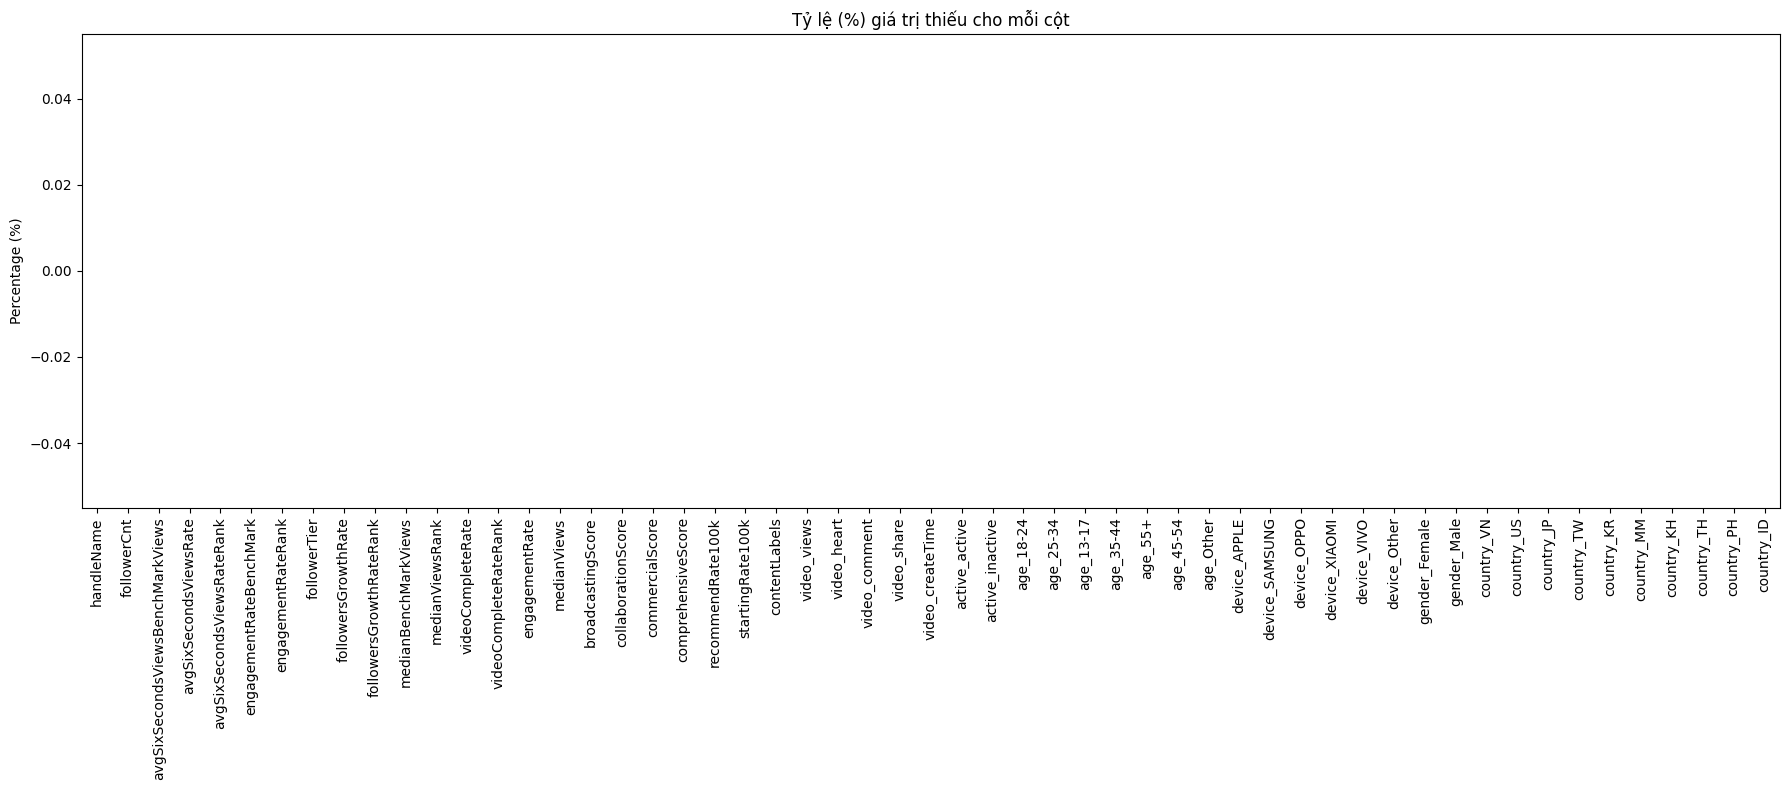

In [14]:
a = df.isna().mean() * 100  

plt.figure(figsize=(18, 8))
a.plot(kind='bar')

plt.title('Tỷ lệ (%) giá trị thiếu cho mỗi cột')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [15]:
df.columns

Index(['handleName', 'followerCnt', 'avgSixSecondsViewsBenchMarkViews',
       'avgSixSecondsViewsRate', 'avgSixSecondsViewsRateRank',
       'engagementRateBenchMark', 'engagementRateRank', 'followerTier',
       'followersGrowthRate', 'followersGrowthRateRank',
       'medianBenchMarkViews', 'medianViewsRank', 'videoCompleteRate',
       'videoCompleteRateRank', 'engagementRate', 'medianViews',
       'broadcastingScore', 'collaborationScore', 'commercialScore',
       'comprehensiveScore', 'recommendRate100k', 'startingRate100k',
       'contentLabels', 'video_views', 'video_heart', 'video_comment',
       'video_share', 'video_createTime', 'active_active', 'active_inactive',
       'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44', 'age_55+',
       'age_45-54', 'age_Other', 'device_APPLE', 'device_SAMSUNG',
       'device_OPPO', 'device_XIAOMI', 'device_VIVO', 'device_Other',
       'gender_Female', 'gender_Male', 'country_VN', 'country_US',
       'country_JP', 'country_TW', 'co

In [16]:
object_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Các cột có kiểu dữ liệu object là:")
print(object_cols)

Các cột có kiểu dữ liệu object là:
['handleName', 'contentLabels']


In [17]:
# Thời điểm crawl dữ liệu
CRAWL_TIME = pd.Timestamp('2026-04-13')

df['video_createTime'] = pd.to_datetime(df['video_createTime'], unit='s')


def creator_features(group: pd.DataFrame) -> pd.Series:
    """
    Tính đặc trưng tổng hợp cho 1 creator từ danh sách video gần đây.
    """
    # --- Tổng tương tác ---
    total_views    = group['video_views'].sum()
    total_hearts   = group['video_heart'].sum()
    total_comments = group['video_comment'].sum()
    total_shares   = group['video_share'].sum()

    # --- Phân phối view ---
    min_view    = group['video_views'].min()
    max_view    = group['video_views'].max()
    median_view = group['video_views'].median()
    mean_view   = group['video_views'].mean()
    std_view    = group['video_views'].std()
    var_view    = group['video_views'].var()

    # Coefficient of Variation — đo biến động tương đối (scale-independent)
    cov_view = std_view / mean_view if mean_view != 0 else np.nan

    # --- Hành vi theo thời gian ---
    times = group['video_createTime'].sort_values()

    # Inter-event time (ngày)
    iet      = times.diff().dt.total_seconds().dropna() / 86400
    mean_iet = iet.mean()
    std_iet  = iet.std()

    # Burstiness: B = (σ/μ − 1) / (σ/μ + 1)
    # B ~ 0 → đều; B > 0 → đăng theo đợt; B < 0 → rất đều
    if mean_iet and mean_iet != 0:
        r = std_iet / mean_iet
        burstiness = (r - 1) / (r + 1)
    else:
        burstiness = np.nan

    # Tổng khoảng thời gian hoạt động (ngày)
    total_span = (times.iloc[-1] - times.iloc[0]).total_seconds() / 86400

    # Recency: khoảng cách video mới nhất → crawl time (ngày), càng nhỏ càng active
    recency = (CRAWL_TIME - times.iloc[-1]).total_seconds() / 86400

    return pd.Series({
        'total_views_recent':      total_views,
        'total_hearts_recent':     total_hearts,
        'total_comments_recent':   total_comments,
        'total_shares_recent':     total_shares,
        'min_view_recent':         min_view,
        'max_view_recent':         max_view,
        'median_view_recent':      median_view,
        'mean_view_recent':        mean_view,
        'std_view_recent':         std_view,
        'var_view_recent':         var_view,
        'cov_view_recent':         cov_view,
        'mean_iet_days_recent':    mean_iet,
        'std_iet_days_recent':     std_iet,
        'burstiness_recent':       burstiness,
        'total_span_days_recent':  total_span,
        'recency_days_recent':     recency,
    })


# Tính features theo creator
creator_df = (
    df.groupby('handleName')
      .apply(creator_features, include_groups=False)
      .reset_index()
)




In [18]:
creator_df.columns

Index(['handleName', 'total_views_recent', 'total_hearts_recent',
       'total_comments_recent', 'total_shares_recent', 'min_view_recent',
       'max_view_recent', 'median_view_recent', 'mean_view_recent',
       'std_view_recent', 'var_view_recent', 'cov_view_recent',
       'mean_iet_days_recent', 'std_iet_days_recent', 'burstiness_recent',
       'total_span_days_recent', 'recency_days_recent'],
      dtype='object')

In [19]:
# Bỏ cột 
DROP_VIDEO_COLS_2 = ['video_views', 'video_heart', 'video_comment','video_share','video_createTime']
df = df.drop(columns=[c for c in DROP_VIDEO_COLS_2 if c in df.columns])

In [20]:
df = df.drop_duplicates()
df.shape

(5092, 50)

In [21]:
# Merge features vào bảng creator
df = df.merge(creator_df, on='handleName', how='left')
print(f'[feature_engineering] Shape: {df.shape}')

[feature_engineering] Shape: (5092, 66)


In [45]:
df[df['followersGrowthRate'] > 1][['handleName','followersGrowthRate']].head(30)

,handleName,followersGrowthRate
335,nhutminnho,2.435717
1198,baochaumacgi,2.054098
1386,thiyen.1901,1.074914
1392,thuybi_cute,98.172643
1394,dtdmusic365,3.204221
1462,slimfitvn,3.177127
1533,gymnewsvn,3.733447
1660,hang.xoy,1.706429
1683,cunnxingieu,1.615325
1715,ranghonho.8,1.073219


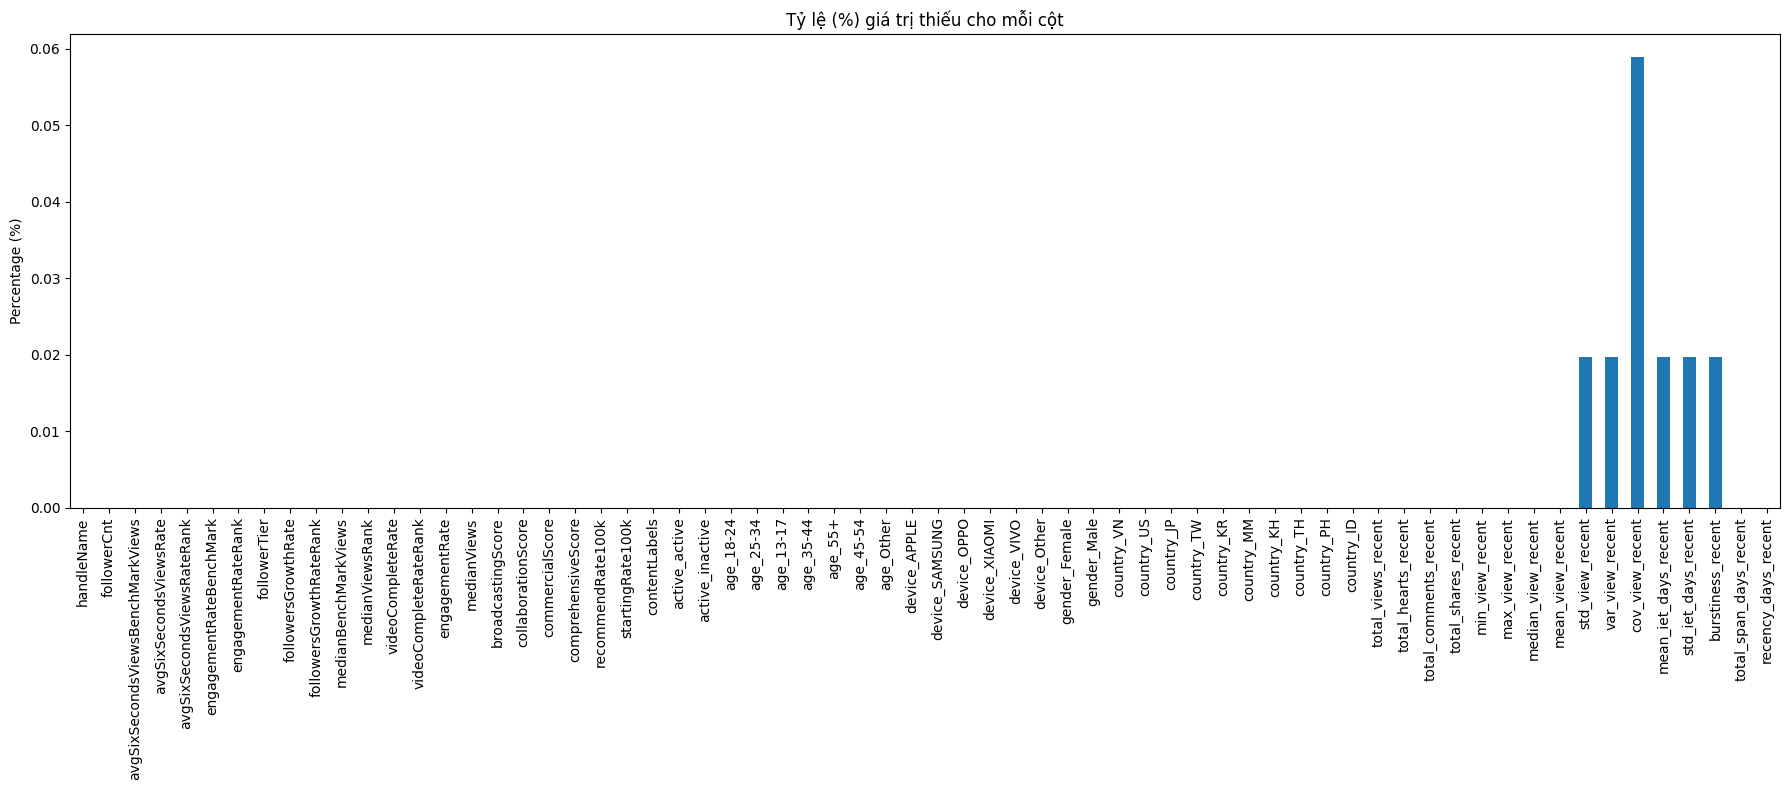

In [22]:
a = df.isna().mean() * 100  

plt.figure(figsize=(18, 8))
a.plot(kind='bar')

plt.title('Tỷ lệ (%) giá trị thiếu cho mỗi cột')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [23]:
cols_check = [
    'std_view_recent',
    'var_view_recent',
    'cov_view_recent',
    'mean_iet_days_recent',
    'std_iet_days_recent',
    'burstiness_recent'
]

df_clean = df.dropna(subset=cols_check).copy()

print("Shape trước:", df.shape)
print("Shape sau:", df_clean.shape)

Shape trước: (5092, 66)
Shape sau: (5089, 66)


In [24]:
import pandas as pd

# 1. Mapping tag -> group
tag_to_group = {
    'School Education': 'Education',
    'Career Development': 'Education',
    'Humanities & Science': 'Education',

    'Fitness': 'Sports',
    'Health & Wellness': 'Sports',
    'Fishing, Hunting, & Camping': 'Sports',
    'Traditional Sports': 'Sports',
    'Extreme Sports': 'Sports',
    'Sports News': 'Sports',

    'Food Display & Reviews': 'Food',
    'Beverages & Production': 'Food',
    'Mukbang & Food Tasting': 'Food',
    'Cooking & Recipes': 'Food',
    'Restaurant Exploration': 'Food',

    'Nail Art & Care': 'Beauty',
    'Beauty Tutorials & Tips': 'Beauty',
    'Hair Design & Care': 'Beauty',
    'Theater & Stage': 'Beauty',

    'Music': 'Entertainment',
    'Dance': 'Entertainment',
    'Animation & Cosplay': 'Entertainment',
    'Entertainment News': 'Entertainment',
    'Supernatural & Horror': 'Entertainment'
}

# 2. Tách label
df_clean['contentLabels_list'] = df_clean['contentLabels'].fillna('').str.split('|')

# 3. Map sang group (unique)
def map_to_groups(labels):
    return list({tag_to_group[label] for label in labels if label in tag_to_group})

df_clean['content_group_list'] = df_clean['contentLabels_list'].apply(map_to_groups)

# 4. Convert sang string cách nhau bằng dấu ,
df_clean['content_group'] = df_clean['content_group_list'].apply(lambda x: ', '.join(x))

In [25]:
df_clean['content_group_list'].value_counts()

content_group_list
[Entertainment]                       2401
[Beauty]                              1132
[Food]                                 923
[Entertainment, Beauty]                164
[Education]                            156
[Beauty, Food]                         111
[Sports, Entertainment]                 55
[Entertainment, Food]                   48
[Sports, Beauty]                        33
[Sports, Food]                          27
[Education, Entertainment]              27
[Education, Beauty]                      5
[Beauty, Entertainment, Food]            2
[Education, Food]                        2
[Education, Entertainment, Sports]       1
[Education, Sports]                      1
[Sports, Beauty, Food]                   1
Name: count, dtype: int64

In [26]:
from sklearn.preprocessing import MultiLabelBinarizer

# ===== 4. One-hot encoding multi-label =====
mlb = MultiLabelBinarizer()

labels_encoded = mlb.fit_transform(df_clean['content_group_list'])

df_labels = pd.DataFrame(labels_encoded, columns=mlb.classes_, index=df_clean.index)

# ===== 5. Gộp lại dataframe =====
df_clean_onehot = pd.concat([df_clean, df_labels], axis=1)


In [27]:
df_labels

,Beauty,Education,Entertainment,Food,Sports
0,0,0,1,0,0
1,0,0,1,0,0
2,1,0,1,0,0
3,0,0,1,0,0
4,0,0,1,0,0
...,...,...,...,...,...
5087,1,0,0,0,0
5088,1,0,0,0,0
5089,1,0,0,0,0
5090,1,0,0,0,0


In [28]:
df_clean_onehot.shape

(5089, 74)

In [29]:
# =========================
# 1. Channel size
# =========================
channel_size_cols = [
    'followerCnt', 
    'startingRate100k',
    'recommendRate100k', 
]

# =========================
# 2. Rank features
# =========================
rank_cols = [
    'followersGrowthRateRank',
    'avgSixSecondsViewsRateRank',
    'medianViewsRank',
    'videoCompleteRateRank',
    'engagementRateRank'
]

# =========================
# 3. Benchmark features
# =========================
benchmark_cols = [
    'avgSixSecondsViewsBenchMarkViews',
    'medianBenchMarkViews',
    'engagementRateBenchMark'
]

# =========================
# 4. Performance 
# =========================
performance_cols = [
    'followersGrowthRate',
    'avgSixSecondsViewsRate',
    'videoCompleteRate',
    'engagementRate',
    'medianViews',
    'broadcastingScore',
    'collaborationScore',
    'commercialScore',
    
    
]

# =========================
# 5. Audience distribution
# =========================
audience_cols = [
    'active_active', 'active_inactive',
    'age_18-24', 'age_25-34', 'age_13-17',
    'age_35-44', 'age_55+', 'age_45-54', 'age_Other',
    'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
    'device_XIAOMI', 'device_VIVO', 'device_Other',
    'gender_Female', 'gender_Male',
    'country_VN', 'country_US', 'country_JP', 'country_TW',
    'country_KR', 'country_MM', 'country_KH',
    'country_TH', 'country_PH', 'country_ID'
]

# =========================
# 6. Content group (one-hot)
# =========================
content_cols = [
    'Beauty', 'Education', 'Entertainment', 'Food', 'Sports'
]

# =========================
# 7. Performance recent (từ 15 video gần nhất)
# =========================
performance_recent_cols = [
    'total_views_recent',        # quy mô kết quả gần đây
    'total_hearts_recent',       # tương tác tổng
    'total_comments_recent',


    'median_view_recent',        # hiệu suất điển hình
    'max_view_recent',           # khả năng bùng nổ

    'cov_view_recent',

    'burstiness_recent',
    'recency_days_recent'

]


In [30]:
df1= df [rank_cols]

In [31]:
import math
def plot_distribution_2fig(df, bins=30, figsize_hist=(16, 10), figsize_box=(14, 6)):
    """
    Vẽ 2 hình cho DataFrame:
    1) Histogram cho tất cả cột numeric
    2) Boxplot cho tất cả cột numeric
    """
    df_num = df.select_dtypes(include=[np.number]).copy()
    
    if df_num.shape[1] == 0:
        raise ValueError("DataFrame không có cột numeric.")
    
    cols = df_num.columns.tolist()
    
    # Hình 1: Histogram grid
    n = len(cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize_hist)
    axes = np.array(axes).reshape(-1)
    
    for i, col in enumerate(cols):
        axes[i].hist(df_num[col].dropna(), bins=bins)
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle("Histogram distributions", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Hình 2: Boxplot
    plt.figure(figsize=figsize_box)
    df_num.boxplot(rot=45)
    plt.title("Boxplot distributions")
    plt.tight_layout()
    plt.show()

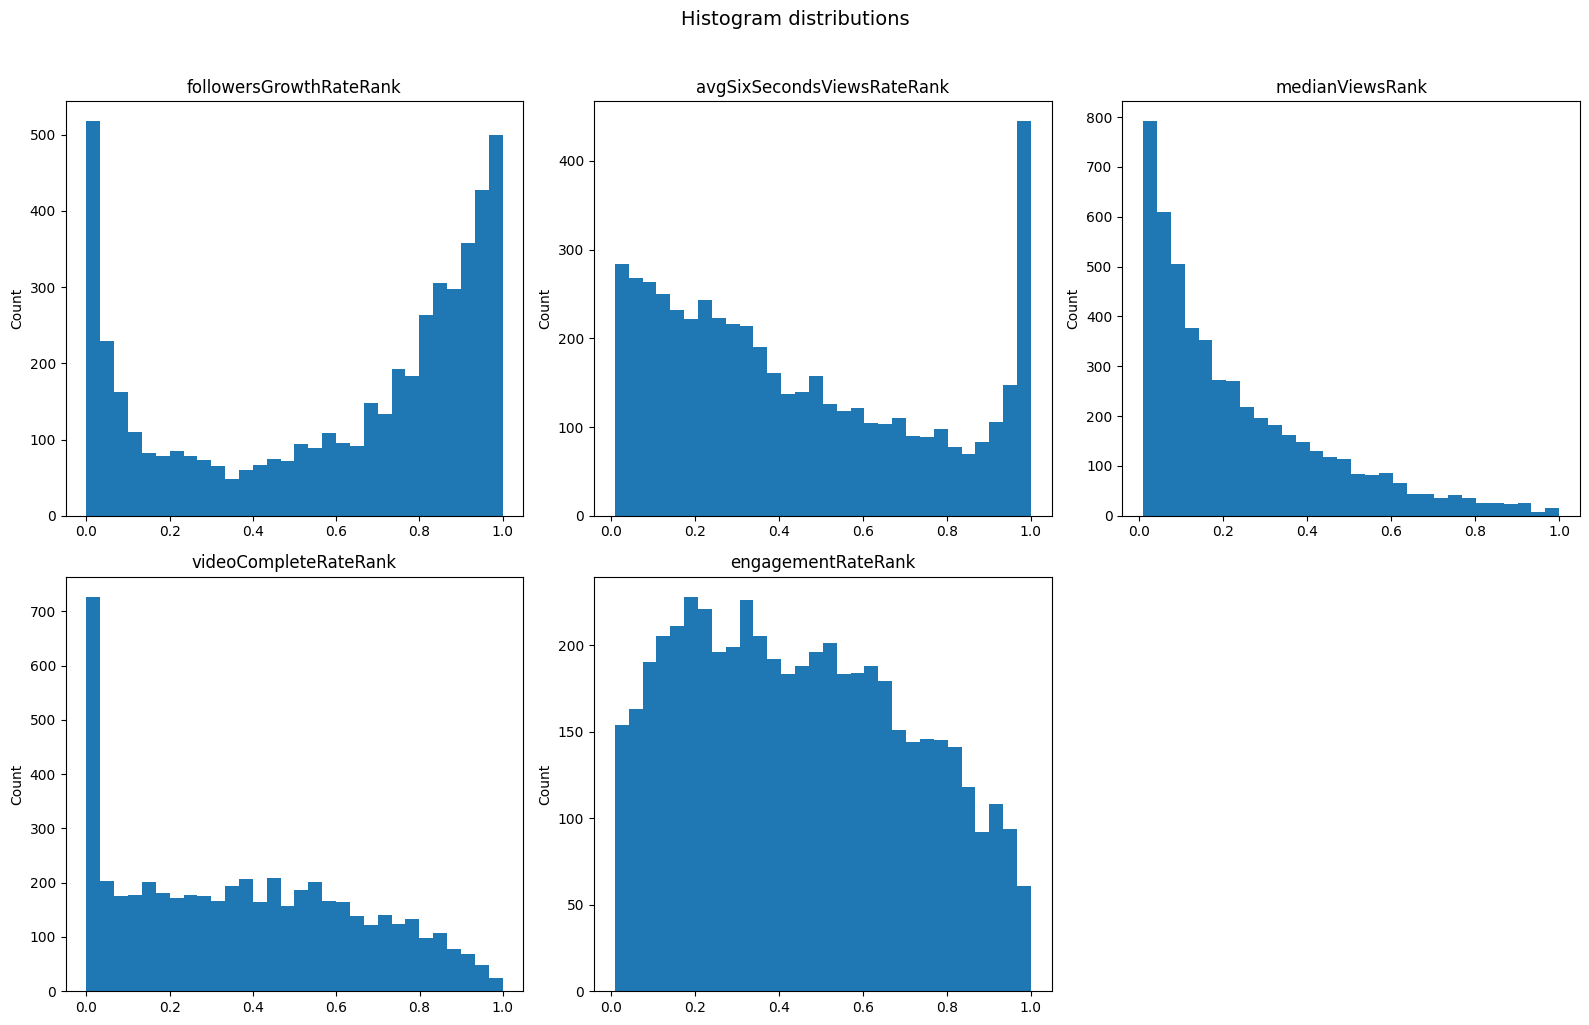

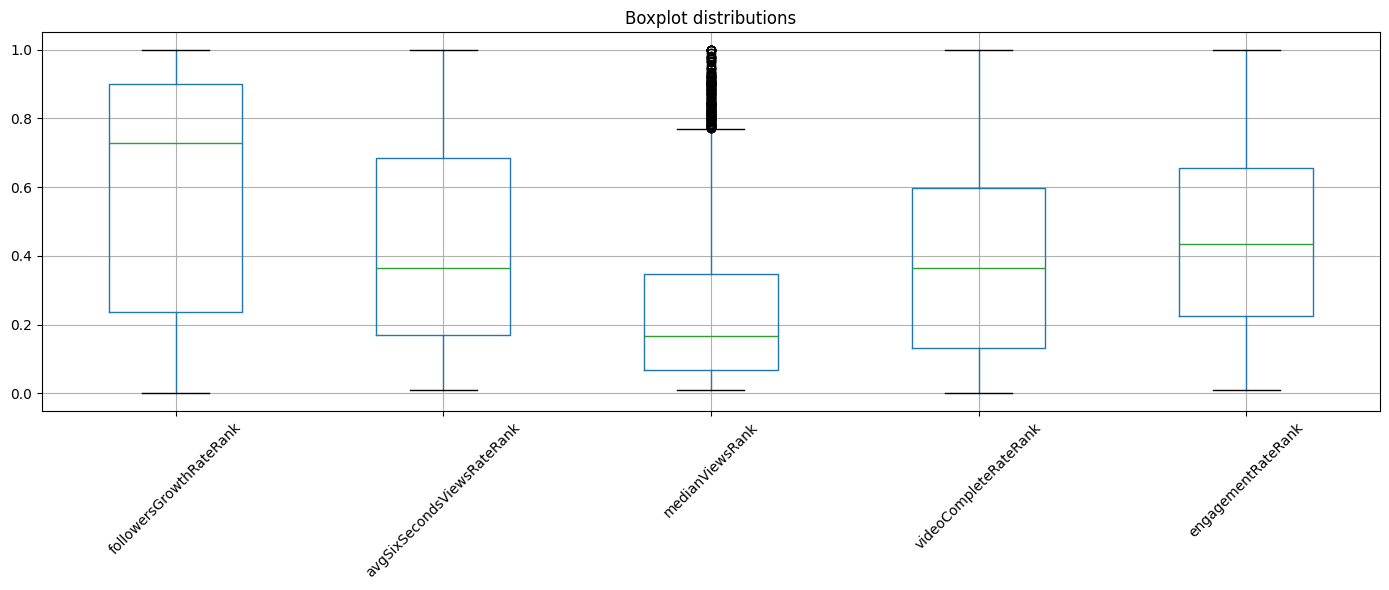

In [32]:
plot_distribution_2fig(df1)

In [33]:
selected_columns = (
    channel_size_cols +
    rank_cols +
    benchmark_cols +
    performance_cols +
    audience_cols +
    content_cols + performance_recent_cols
)

In [34]:
# chỉ giữ các cột tồn tại trong df 
selected_columns = [col for col in selected_columns if col in df_clean_onehot.columns]

df_model = df_clean_onehot[selected_columns].copy()

In [35]:
print("Shape:", df_model.shape)
print("Missing values:", df_model.isna().sum().sum())

Shape: (5089, 59)
Missing values: 0


In [36]:
def basic_overview(df):
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    print("\nData types:")
    print(df.dtypes.value_counts())

basic_overview(df_model)

Shape: (5089, 59)

Missing values:
followerCnt      0
country_PH       0
device_VIVO      0
device_Other     0
gender_Female    0
gender_Male      0
country_VN       0
country_US       0
country_JP       0
country_TW       0
country_KR       0
country_MM       0
country_KH       0
country_TH       0
country_ID       0
device_OPPO      0
Beauty           0
Education        0
Entertainment    0
Food             0
dtype: int64

Data types:
float64    51
int32       5
int64       3
Name: count, dtype: int64


In [3]:
df_model = pd.read_csv('model_features.csv')

In [4]:


def column_stats(df):
    stats = []

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            s = df[col].dropna()

            stats.append({
                'column': col,
                'min': s.min(),
                'max': s.max(),
                'mean': s.mean(),
                'median': s.median(),
                'std': s.std(),
                'skew': s.skew(),
                'kurtosis': s.kurt(),
                'q1': s.quantile(0.25),
                'q3': s.quantile(0.75),
                'iqr': s.quantile(0.75) - s.quantile(0.25),
                'zero_ratio': (s == 0).mean(),
                'unique': s.nunique()
            })

    return pd.DataFrame(stats).sort_values(by='skew', ascending=False)



In [5]:
stats_df = column_stats(df_model)
stats_df.to_csv('feature_stats.csv', index=False)

In [6]:
stats_df.head(60)

,column,min,max,mean,median,std,skew,kurtosis,q1,q3,iqr,zero_ratio,unique
51,total_views_recent,2068.000000,9.634141e+08,3.153143e+06,1.194663e+06,1.477170e+07,54.500358,3513.496524,5.056890e+05,2.825687e+06,2.319998e+06,0.000000,5087
52,total_hearts_recent,0.000000,2.584405e+07,3.067029e+04,3.040000e+03,4.177759e+05,52.229331,3033.642705,6.760000e+02,1.192100e+04,1.124500e+04,0.000590,3950
11,followersGrowthRate,-0.154088,4.203700e+04,1.737741e+01,3.702500e-03,8.132967e+02,50.221039,2530.924471,-1.874414e-03,3.110764e-02,3.298206e-02,0.001965,5080
55,max_view_recent,495.000000,2.509662e+08,1.104868e+06,3.659750e+05,4.178282e+06,43.081724,2519.160121,1.343280e+05,1.001048e+06,8.667200e+05,0.000000,5078
40,country_KR,0.000000,4.889027e-01,2.733627e-03,0.000000e+00,9.177007e-03,32.311099,1579.565549,0.000000e+00,4.400282e-03,4.400282e-03,0.575162,2163
2,recommendRate100k,0.000000,7.161373e+13,3.811879e+11,1.226300e+11,1.356064e+12,31.223297,1520.516829,4.466247e+10,3.299726e+11,2.853101e+11,0.003537,4460
1,startingRate100k,0.000000,1.150000e+14,3.160794e+11,0.000000e+00,3.371246e+12,28.420379,863.928597,0.000000e+00,1.000000e+11,1.000000e+11,0.644331,203
38,country_JP,0.000000,4.936800e-01,4.755977e-03,1.748119e-03,1.550758e-02,19.471318,480.669404,0.000000e+00,6.612571e-03,6.612571e-03,0.460798,2745
39,country_TW,0.000000,5.832739e-01,5.779939e-03,1.861944e-03,1.907594e-02,17.633849,435.908577,0.000000e+00,6.840620e-03,6.840620e-03,0.451562,2792
42,country_KH,0.000000,9.195298e-01,7.321621e-03,0.000000e+00,3.906105e-02,15.098860,288.770259,0.000000e+00,3.202293e-03,3.202293e-03,0.660641,1728
